# Naive Bayes From Scratch

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

### Data Analysis

In [2]:
df = pd.read_csv('../../../data/breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
px.histogram(data_frame=df, x='diagnosis', color='diagnosis', color_discrete_sequence=['black', 'red'])

In [4]:
px.histogram(data_frame=df,x='area_mean',color='diagnosis',color_discrete_sequence=['black','red'])

In [5]:
px.histogram(data_frame=df,x='radius_mean',color='diagnosis',color_discrete_sequence=['black','red'])

In [6]:
px.histogram(data_frame=df,x='perimeter_mean',color='diagnosis',color_discrete_sequence=['black','red'])

In [7]:
px.histogram(data_frame=df,x='smoothness_mean',color='diagnosis',color_discrete_sequence=['black','red'])

In [8]:
px.histogram(data_frame=df,x='texture_mean',color='diagnosis',color_discrete_sequence=['black','red'])

In [9]:
px.scatter(data_frame=df,x='symmetry_worst',color='diagnosis',color_discrete_sequence=['black','red'])

In [10]:
px.scatter(data_frame=df,x='concavity_worst',color='diagnosis',color_discrete_sequence=['black','red'])

In [11]:
px.scatter(data_frame=df,x='fractal_dimension_worst',color='diagnosis',color_discrete_sequence=['black','red'])

### Data Preprocessing

In [12]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [14]:
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)  #encode the label into 1/0

In [15]:
corr = df.corr()

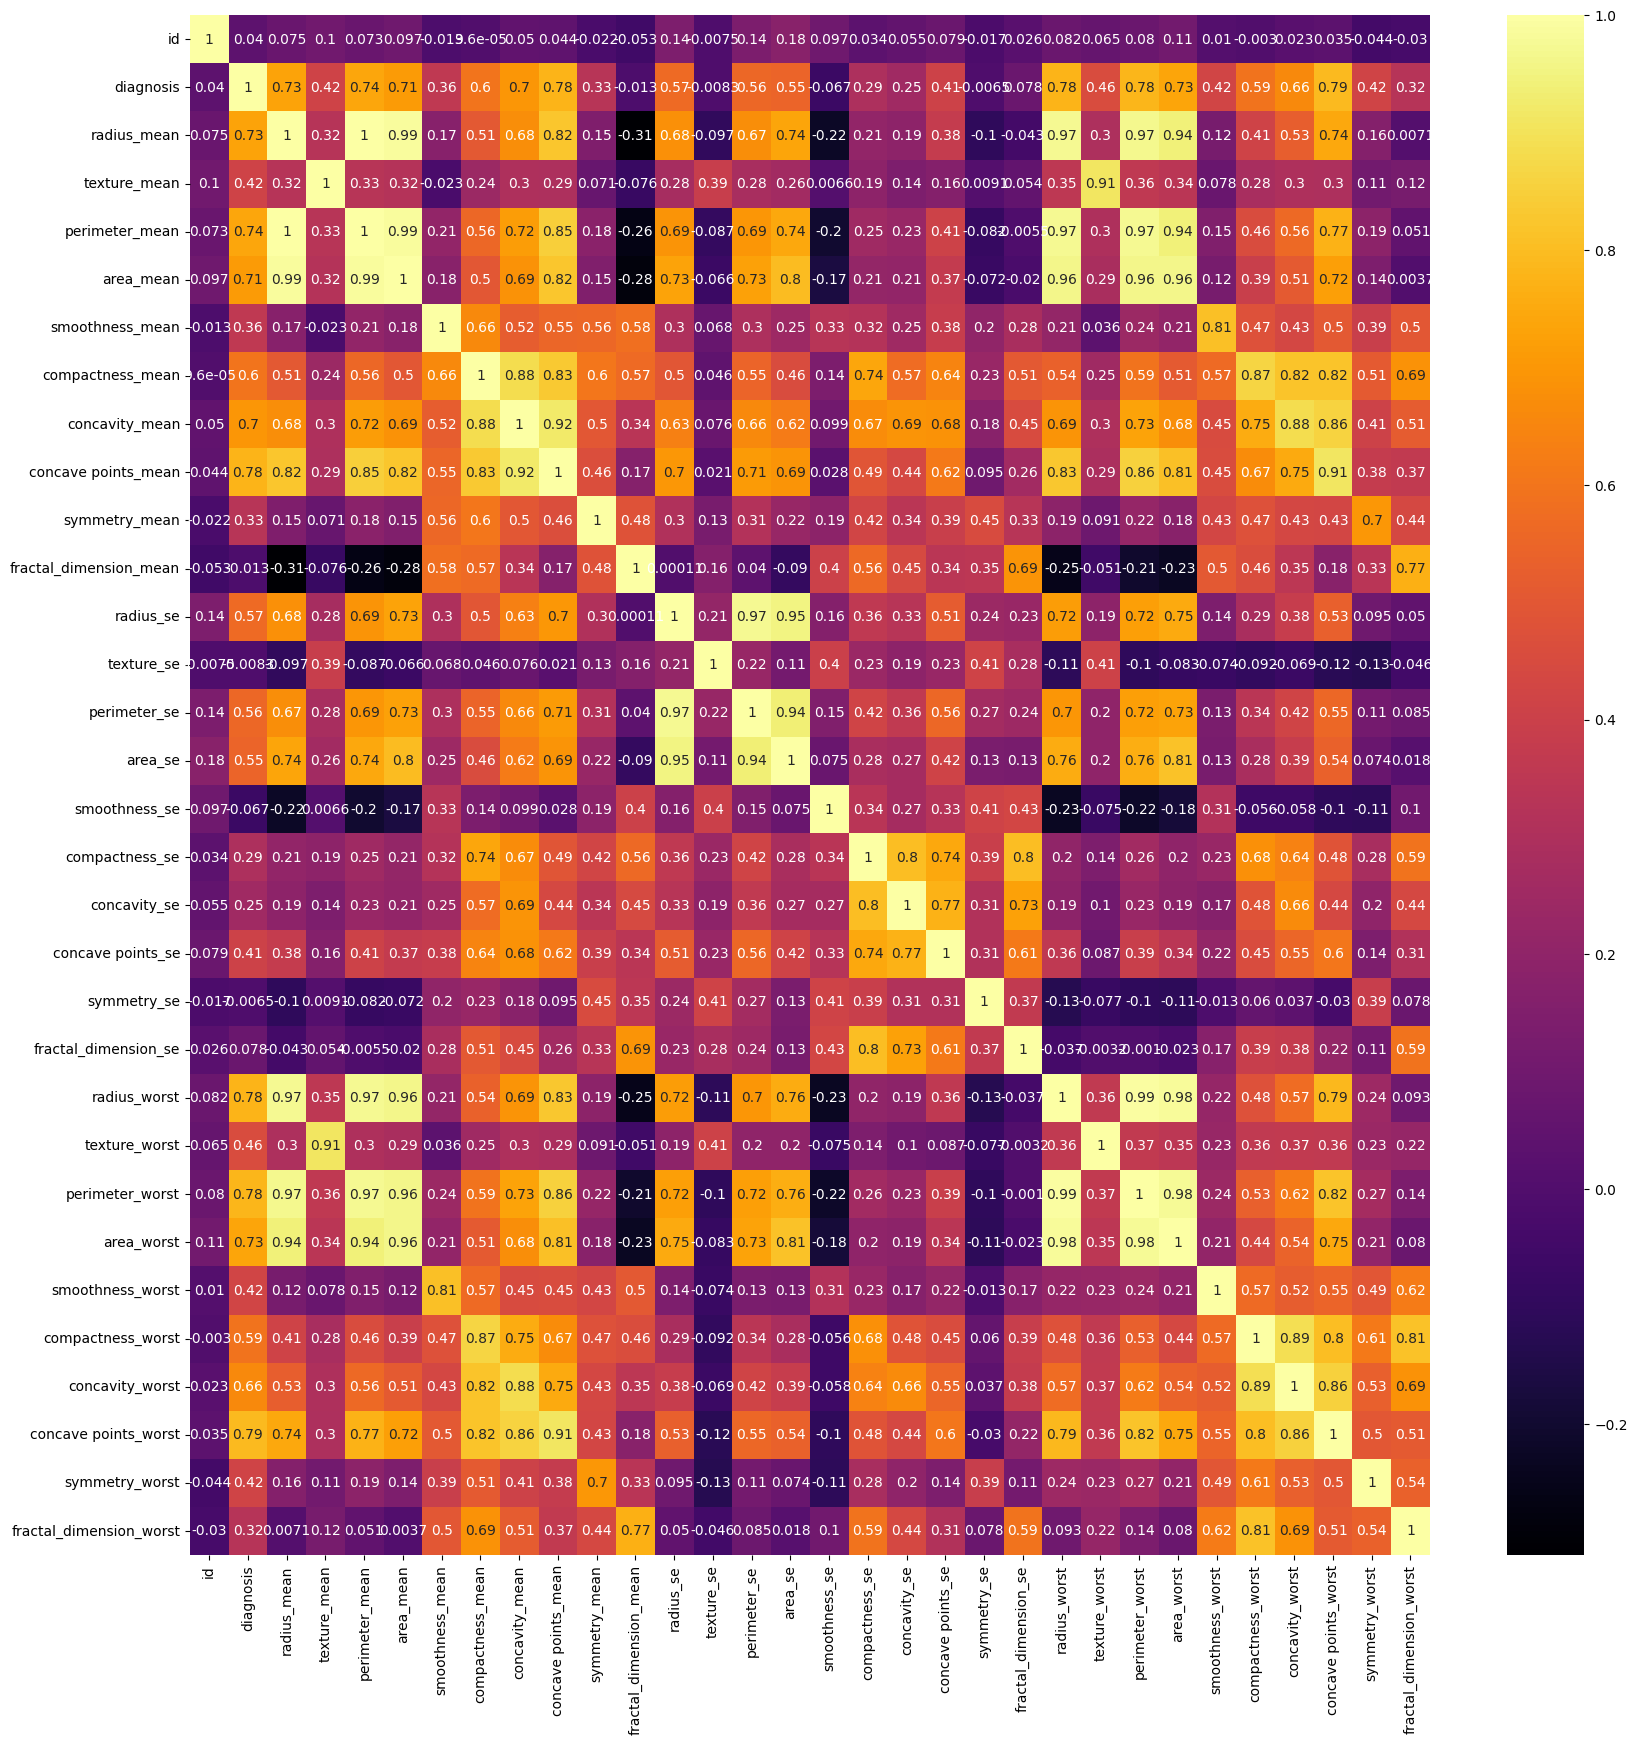

In [16]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr, cmap='inferno', annot=True)
plt.show()

In [17]:
# Get the absolute value of the correlation
cor_target = abs(corr['diagnosis'])

# Select highly correlated features (threshold = 0.2)
relevant_features = cor_target[cor_target > 0.2]

# Collet the names of the features
names = [index for index, value in relevant_features.items()]

names.remove('diagnosis')

print(names)

['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'concavity_se', 'concave points_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


### Assign data and labels

In [18]:
X = df[names].values
y = df['diagnosis']

#### Scaling Data

In [19]:
def scale(X):
    """
    Standardizes the data in the array X.

    Parameters:
        X (numpy.ndarray): Features array of shape (n_samples, n_features).

    Returns:
        numpy.ndarray: The standardized features array.
    """

    mean = np.mean(X, axis = 0)
    std = np.std(X, axis = 0)

    # Standardize the data
    X = (X - mean) / std
    return X

In [20]:
X = scale(X)

In [21]:
def train_test_split(X, y, random_state=41, test_size=0.2):
    """
    Splits the data into training and testing sets.

    Parameters:
        X (numpy.ndarray): Features array of shape (n_samples, n_features).
        y (numpy.ndarray): Target array of shape (n_samples,).
        random_state (int): Seed for the random number generator. Default is 42.
        test_size (float): Proportion of samples to include in the test set. Default is 0.2.

    Returns:
        Tuple[numpy.ndarray]: A tuple containing X_train, X_test, y_train, y_test.
    """
    # Get number of samples
    n_samples = X.shape[0]

    # Set the seed for the random number generator
    np.random.seed(random_state)

    # Shuffle the indices
    shuffled_indices = np.random.permutation(np.arange(n_samples))

    # Determine the size of the test set
    test_size = int(n_samples * test_size)

    # Split the indices into test and train
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]

    # Split the features and target arrays into test and train
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42) #split the  data into traing and validating

### Model Implementation

Naive Bayes Depends on Bayesian Theorem is represnted by this formula:
$$P(y|X) = \frac{P(X|y) \cdot P(y)}{P(X)}$$
Where y is the label, X is the features

<h3>Let's break down the formula</h3>

$P(y|X)$ is called the posterior where it's the probability "after" the evidence is considered.

$P(y)$ is called the prior where it's the probability "before" the evidence is considered.

$P(X|y)$ is called the Likelihood where it's the probability of the evidence given the belief is true.

$P(X)$ is called the Margin where it's the probability of the evidence in any case (We won't need that for our case)

#### So, why is it called "Naive"?
Naive Bayes is called naive because it makes the assumption that the features are independent of each other.

#### Goals
Our goal is to maximize the posterior, so we'll choose the y that does so

#### Implementation Notes:

We'll need to store the mean, the variance, and the prior

$P(y)$ (the prior) is the number of elements in certain class/ number of all elements in all classes

We'll assume that the data's underlying distribution is Gaussian
$$f(x) = \frac{1}{\sigma \sqrt(2\pi)} \text{exp}(-\frac{1}{2} \frac{(x - \mu)^2}{\sigma^2})$$

We'll split $P(X|y)$ (the posterior) to $\log(P(x_1 |y)) + \log(P(x_2|y)) + \log(P(x_3 | y)) + ... + \log(P(x_n |y))$

Here we are using log to avoid getting very small numbers that aren't interpretable..

So $y$ will be $\text{argmax} [\text{(the posterior)} + \log(P(P_y))]$